In [42]:
#importing data analysis libraries
import pandas as pd
import numpy as np

# Q1. Data Cleaning: Identifying and Handling Missing Values

In [2]:
df = pd.read_csv('train.csv')

In [3]:
#reviewing the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#locating if there are any empty value columns in the dataset
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Handling missing values

In [6]:
#filling the empty rows with mean value
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

## Removing Irrelevent Columns


In [7]:
df = df.drop(columns= ['Name', 'Ticket', 'Cabin', 'PassengerId'])

In [8]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [12]:
# reviewing the new shape of the dataframe
df.shape

(891, 8)

# Q2. Data Scaling (Normalization)

In [13]:
#importing libraries
from sklearn.preprocessing import MinMaxScaler

In [14]:
#creating object of MinMaxScaler
scaler = MinMaxScaler()

In [15]:
#applying scaling to continous numerical columns
df[['scaled_age', 'scaled_fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# Q3. Data Binning: Categorizing Age and Fare Values

## Part A: Categorizing Age

In [18]:
#identifying the minimum and maximum age
print(df['Age'].min(), df['Age'].max())

0.42 80.0


In [20]:
age_category = [0, 19, 39, 59, 100]
age_labels =  ['Young', 'Adult', 'Middle-Aged', 'Senior']

In [21]:
#creating age group column
df['Age_Group'] = pd.cut(df['Age'], bins =age_category, labels= age_labels)

In [22]:
#import matplotlib to represent graphs
import matplotlib.pyplot as plt

In [23]:
#to display frequencies of age count
age_cnt = df['Age_Group'].value_counts()

In [24]:
age_cnt

,count
Age_Group,
Adult,564
Young,164
Middle-Aged,137
Senior,26


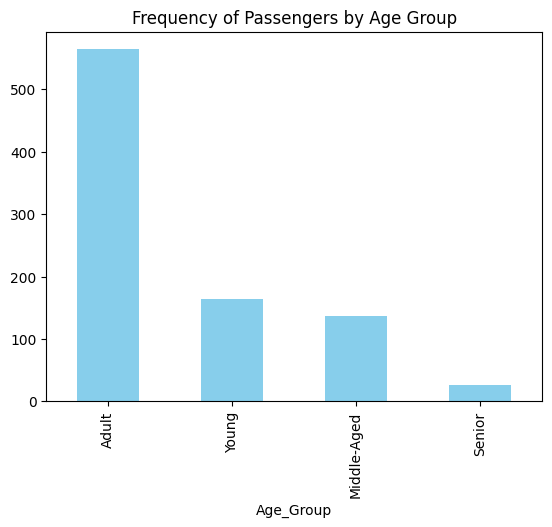

In [25]:
# to display the bar graph of the Age_Group
age_cnt.plot(kind = 'bar', color = 'skyblue', title = 'Frequency of Passengers by Age Group')
plt.show()

In [29]:
#comparing survival rates along the different age groups
print("Survival rate by Age_group: \n", df.groupby('Age_Group')['Survived'].mean())

Survival rate by Age_group: 
 Age_Group
Young          0.481707
Adult          0.358156
Middle-Aged    0.394161
Senior         0.269231
Name: Survived, dtype: float64


/tmp/ipykernel_2865/3751474713.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("Survival rate by Age_group: \n", df.groupby('Age_Group')['Survived'].mean())


/tmp/ipykernel_2865/99253115.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Survived'].mean().plot(kind='bar', color='Green',  title='Survival Rate Comparision based on Age_Groups')


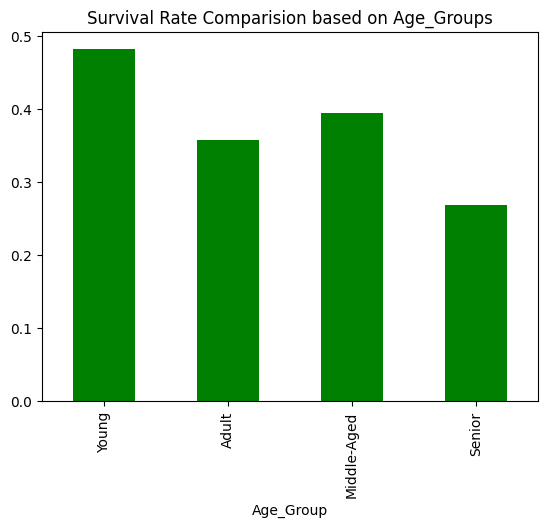

In [32]:
# displaying the same using a bar graph
df.groupby('Age_Group')['Survived'].mean().plot(kind='bar', color='Green',  title='Survival Rate Comparision based on Age_Groups')
plt.show()

## Part B: Categorizing Fare Values

In [38]:
minFare = df['Fare'].min()
maxFare = df['Fare'].max()
meanFare= df['Fare'].mean()
print(f'minimun fare = {minFare} \nmaximum fare = {maxFare} \nmean fare = {meanFare} ')

minimun fare = 0.0 
maximum fare = 512.3292 
mean fare = 32.204207968574636 


In [39]:
#Dividing the Fare Categories
df['FareCategory'] = pd.qcut(df['Fare'], q= 4, labels=['Low_Fare', 'Medium_Fare', 'High_Fare', 'Very_High_Fare' ])

In [40]:
# Comparison of survival rate based on Fare Category
print("Survival Rate based on Fare = ", df.groupby('FareCategory')['Survived'].mean())

Survival Rate based on Fare =  FareCategory
Low_Fare          0.197309
Medium_Fare       0.303571
High_Fare         0.454955
Very_High_Fare    0.581081
Name: Survived, dtype: float64


/tmp/ipykernel_2865/2322623873.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("Survival Rate based on Fare = ", df.groupby('FareCategory')['Survived'].mean())


/tmp/ipykernel_2865/3720309896.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('FareCategory')['Survived'].mean().plot(kind='bar', color= 'skyblue', title='Survival Rate based on Fare_Category')


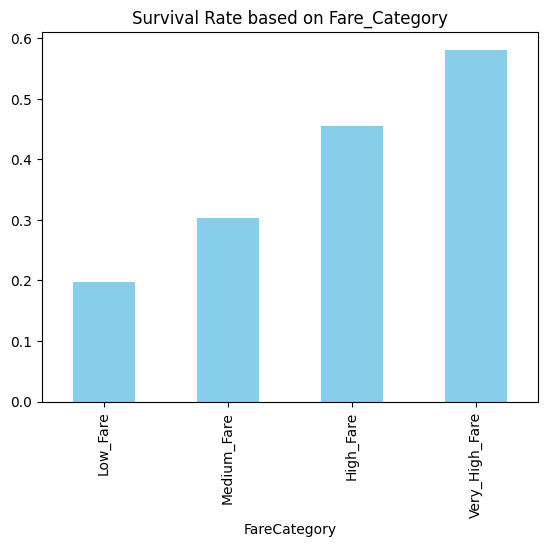

In [41]:
#plotting the comparision on a bar graph
df.groupby('FareCategory')['Survived'].mean().plot(kind='bar', color= 'skyblue', title='Survival Rate based on Fare_Category')
plt.show()


# Q4. Creating and Categorizing Family Size

In [43]:
#Creting a Feature : FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [44]:
family_bins = [0, 1, 4, 6, 20]

In [47]:
#Categorzing Family according to their size into different groups
family_labels = ['Alone', 'Small Family', 'Medium Family', 'Large Family']
df['FamilyCategory'] = pd.cut(df['FamilySize'], bins = family_bins, labels = family_labels)

In [48]:
#showing the frequencies of family size
print("Passengers per Family Category = \n",df['FamilyCategory']. value_counts() )

Passengers per Family Category = 
 FamilyCategory
Alone            537
Small Family     292
Medium Family     37
Large Family      25
Name: count, dtype: int64


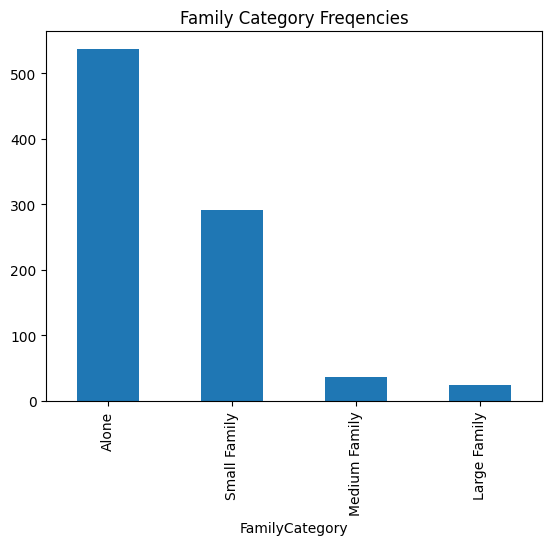

In [50]:
#showing frequency of family category on a bar graph
df['FamilyCategory']. value_counts().plot(kind = 'bar', title = 'Family Category Freqencies')
plt.show()

In [51]:
#showing the survival rate based on family size
print("Survival Rate by Family Size = \n", df.groupby('FamilyCategory')['Survived'].mean())

Survival Rate by Family Size = 
 FamilyCategory
Alone            0.303538
Small Family     0.578767
Medium Family    0.162162
Large Family     0.160000
Name: Survived, dtype: float64


/tmp/ipykernel_2865/925528521.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("Survival Rate by Family Size = \n", df.groupby('FamilyCategory')['Survived'].mean())


/tmp/ipykernel_2865/647133834.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('FamilyCategory')['Survived'].mean().plot(kind= 'pie', autopct= '%1.1f%%' ,title = 'Survival Rate based on Family Size')


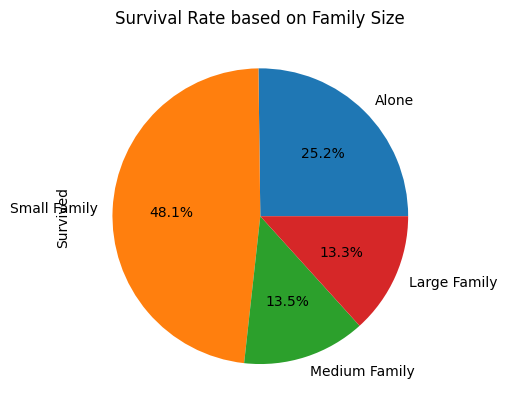

In [54]:
#ploting the pie graph for the survival rate of family based on their size
df.groupby('FamilyCategory')['Survived'].mean().plot(kind= 'pie', autopct= '%1.1f%%' ,title = 'Survival Rate based on Family Size')
plt.show()